## Neural Network Model:

In [2]:
import copy
import pandas as pd
import numpy as np
import time
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import random
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

In [3]:
df = pd.read_excel("dom_demand_va_weather.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22534 entries, 0 to 22533
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   datetime                 22534 non-null  datetime64[ns]
 1   subregion_code           22534 non-null  object        
 2   subregion_name           22534 non-null  object        
 3   parent_code              22534 non-null  object        
 4   parent_name              22534 non-null  object        
 5   demand_mwh               22534 non-null  int64         
 6   value-units              22534 non-null  object        
 7   air_temp_mean            22534 non-null  float64       
 8   air_temp_min             22534 non-null  float64       
 9   air_temp_max             22534 non-null  float64       
 10  dew_point_mean           22534 non-null  float64       
 11  sea_level_pressure_mean  22534 non-null  float64       
 12  wind_speed_mean          22534 n

In [4]:
df["hour_of_day"] = df['datetime'].dt.hour
df["month"] = df['datetime'].dt.month
df["year"] = df['datetime'].dt.year
df["weekday"] = df['datetime'].dt.weekday

In [5]:
df.head()

,datetime,subregion_code,subregion_name,parent_code,parent_name,demand_mwh,value-units,air_temp_mean,air_temp_min,air_temp_max,dew_point_mean,sea_level_pressure_mean,wind_speed_mean,precip_1hr_mean,precip_1hr_max,station_count,hour_of_day,month,year,weekday
0,2023-01-01 00:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12906,megawatthours,13.640000,10.0,17.9,12.583333,1011.790000,2.418182,NaN,NaN,11,0,1,2023,6
1,2023-01-01 01:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12562,megawatthours,13.881081,7.8,18.9,13.150000,1011.966667,3.250000,1.460878,6.4,40,1,1,2023,6
2,2023-01-01 02:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",12188,megawatthours,13.778947,8.0,19.4,13.018182,1012.086364,3.527500,1.600004,7.1,40,2,1,2023,6
3,2023-01-01 03:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",11785,megawatthours,13.107895,6.8,19.4,12.369697,1012.141667,2.555000,0.926109,7.9,40,3,1,2023,6
4,2023-01-01 04:00:00,DOM,Dominion Virginia Power zone,PJM,"PJM Interconnection, LLC",11428,megawatthours,12.241176,7.8,17.2,11.769697,1012.040000,2.605000,0.023565,0.2,40,4,1,2023,6


In [6]:
print(df["subregion_code"].unique())
print(df["subregion_name"].unique())
print(df["parent_code"].unique())
print(df["parent_name"].unique())
print(df["value-units"].unique())
print(df["weekday"].unique())

['DOM']
['Dominion Virginia Power zone']
['PJM']
['PJM Interconnection, LLC']
['megawatthours']
[6 0 1 2 3 4 5]


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22534 entries, 0 to 22533
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   datetime                 22534 non-null  datetime64[ns]
 1   subregion_code           22534 non-null  object        
 2   subregion_name           22534 non-null  object        
 3   parent_code              22534 non-null  object        
 4   parent_name              22534 non-null  object        
 5   demand_mwh               22534 non-null  int64         
 6   value-units              22534 non-null  object        
 7   air_temp_mean            22534 non-null  float64       
 8   air_temp_min             22534 non-null  float64       
 9   air_temp_max             22534 non-null  float64       
 10  dew_point_mean           22534 non-null  float64       
 11  sea_level_pressure_mean  22534 non-null  float64       
 12  wind_speed_mean          22534 n

In [8]:
exclusion_list = ['datetime','subregion_code','subregion_name','station_count','parent_code','parent_name','value-units','station_count'
                 ,'air_temp_min','air_temp_max','precip_1hr_max'
                 #,'year'
                 ]
full_column_list=list(df.columns)
columns_of_interest = [i for i in full_column_list if i not in exclusion_list]
print(columns_of_interest)

['demand_mwh', 'air_temp_mean', 'dew_point_mean', 'sea_level_pressure_mean', 'wind_speed_mean', 'precip_1hr_mean', 'hour_of_day', 'month', 'year', 'weekday']


In [9]:
df_trimmed = df.loc[:,columns_of_interest].dropna(axis=0)

#For hours, i will try both sin/cos, and one-hot separately:
#sin cos:
#df_trimmed['hour_sin'] = np.sin(2 * np.pi * df_trimmed['hour_of_day'] / 24)
#df_trimmed['hour_cos'] = np.cos(2 * np.pi * df_trimmed['hour_of_day'] / 24)
#one-hot:
df_trimmed = pd.get_dummies(df_trimmed, columns=['hour_of_day'], prefix='hour_of_day', drop_first=True)

#sin cos transformation for month:
df_trimmed['month_sin'] = np.sin(2 * np.pi * df_trimmed['month'] / 12)
df_trimmed['month_cos'] = np.cos(2 * np.pi * df_trimmed['month'] / 12)

#one-hot for day of week:
df_trimmed = pd.get_dummies(df_trimmed, columns=['weekday'], prefix='day', drop_first=True)

#df_trimmed = df_trimmed.drop(columns=['month'
#                                     #,'hour_of_day' #drop it if using sin/cos transformation instead of one-hot
#                                     ])

bool_cols = [col for col in df_trimmed.columns if col.startswith(('day_', 'hour_'))]
df_trimmed[bool_cols] = df_trimmed[bool_cols].astype(int)

In [10]:
df_trimmed.head()

,demand_mwh,air_temp_mean,dew_point_mean,sea_level_pressure_mean,wind_speed_mean,precip_1hr_mean,month,year,hour_of_day_1,hour_of_day_2,...,hour_of_day_22,hour_of_day_23,month_sin,month_cos,day_1,day_2,day_3,day_4,day_5,day_6
1,12562,13.881081,13.150000,1011.966667,3.2500,1.460878,1,2023,1,0,...,0,0,0.5,0.866025,0,0,0,0,0,1
2,12188,13.778947,13.018182,1012.086364,3.5275,1.600004,1,2023,0,1,...,0,0,0.5,0.866025,0,0,0,0,0,1
3,11785,13.107895,12.369697,1012.141667,2.5550,0.926109,1,2023,0,0,...,0,0,0.5,0.866025,0,0,0,0,0,1
4,11428,12.241176,11.769697,1012.040000,2.6050,0.023565,1,2023,0,0,...,0,0,0.5,0.866025,0,0,0,0,0,1
5,11103,12.194737,11.484848,1012.233333,2.5000,0.017647,1,2023,0,0,...,0,0,0.5,0.866025,0,0,0,0,0,1


### Approach 2: Train on 2023, validate on 2024, test on 2025:

In [12]:
target = ["demand_mwh"]
features = [i for i in list(df_trimmed.columns) if i not in target]
y_train = df_trimmed[df_trimmed["year"] == 2023][target]
y_val = df_trimmed[df_trimmed["year"] == 2024][target]
y_test = df_trimmed[df_trimmed["year"] == 2025][target]
x_train = df_trimmed[df_trimmed["year"] == 2023][features]
x_val = df_trimmed[df_trimmed["year"] == 2024][features]
x_test = df_trimmed[df_trimmed["year"] == 2025][features]

#until we have at least 5 years, i will drop year:
x_train = x_train.drop(columns = ["year","month"])
x_test = x_test.drop(columns = ["year","month"])
x_val = x_val.drop(columns = ["year","month"])

In [13]:
columns_to_scale = ['air_temp_mean','dew_point_mean','sea_level_pressure_mean','wind_speed_mean','precip_1hr_mean'
                    #,'year'
                    #,'air_temp_min','air_temp_max','precip_1hr_max'
                   ]
column_transformer = ColumnTransformer([('scaler',StandardScaler(),columns_to_scale)]
                                       , remainder = 'passthrough')
x_train_scaled = column_transformer.fit_transform(x_train)
x_test_scaled = column_transformer.transform(x_test)
x_val_scaled = column_transformer.transform(x_val)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))

In [14]:
class ElectricityDemandNN(nn.Module):
    def __init__(self, input_dim):
        super(ElectricityDemandNN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


def prepare_data(X_train, y_train, X_val, y_val, batch_size=32):
    X_train_t = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32).view(-1, 1)
    
    X_val_t = torch.tensor(X_val.values if hasattr(X_val, 'values') else X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.values if hasattr(y_val, 'values') else y_val, dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader


def train_model(X_train, y_train, X_val, y_val):
    learning_rate = 0.001
    epochs = 200
    patience = 20
    
    input_dim = X_train.shape[1]
    model = ElectricityDemandNN(input_dim)
    criterion = nn.MSELoss() 
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader, val_loader = prepare_data(X_train, y_train, X_val, y_val)
    
    best_loss = float('inf')
    epochs_without_improvement = 0
    
    # Start timer
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                preds = model(batch_X)
                val_loss += criterion(preds, batch_y).item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={avg_train:.4f}, Val Loss={avg_val:.4f}")

        if avg_val < best_loss:
            best_loss = avg_val
            epochs_without_improvement = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    # Stop timer
    total_time = time.time() - start_time
    
    model.load_state_dict(torch.load('best_model.pth'))
    return model, total_time

In [15]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)
model, training_time = train_model(x_train_scaled, y_train_scaled, x_val_scaled, y_val_scaled)

Epoch 0: Train Loss=0.2637, Val Loss=0.2384
Epoch 10: Train Loss=0.0299, Val Loss=0.2393
Epoch 20: Train Loss=0.0198, Val Loss=0.1750
Epoch 30: Train Loss=0.0138, Val Loss=0.1735
Early stopping triggered at epoch 33


In [16]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

def get_predictions(model, X_test_scaled, y_scaler):
    model.eval()
    
    X_test_t = torch.tensor(
        X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled,
        dtype=torch.float32
    )

    with torch.no_grad():
        predictions_scaled = model(X_test_t).cpu().numpy()
    
    predictions = y_scaler.inverse_transform(predictions_scaled).ravel()
    
    return predictions

In [17]:
y_pred = get_predictions(model, x_test_scaled, y_scaler)
y_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()

r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
bias = np.mean(y_pred - y_true)

print("\n" + "="*60)
print("Test Metrics - 2025:")
print(f"  R-squared:  {r2:.4f}")
print(f"  MSE:   {mse:.0f}")
print(f"  RMSE:  {rmse:.0f} MW")
print(f"  MAE:   {mae:.0f} MW")
print(f"  MAPE:  {mape:.2f}%")
print(f"  Bias:  {bias:.0f} MW")
print(f"Training time: {training_time:.3f} seconds")


Test Metrics - 2025:
  R-squared:  0.6645
  MSE:   2700379
  RMSE:  1643 MW
  MAE:   1527 MW
  MAPE:  9.84%
  Bias:  -1517 MW
Training time: 11.470 seconds


In [18]:
# Approach: Train on 2023+2024 combined, test on 2025
# Quick val slice from train for early stopping (85/15 % split)
# No scaling — neither features nor target

seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

train_df = df_trimmed[df_trimmed["year"].isin([2023, 2024])]
test_df = df_trimmed[df_trimmed["year"] == 2025]

feature_cols = [c for c in df_trimmed.columns 
                if c not in ["demand_mwh", "year", "month"]]

X_full_train = train_df[feature_cols]
y_full_train = train_df[["demand_mwh"]]
X_test_2025 = test_df[feature_cols]
y_test_2025 = test_df[["demand_mwh"]]

# Carve val from combined train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full_train, y_full_train, test_size=0.15, random_state=1, shuffle=True
)

# Train using the existing function (no scaling, raw values)
model_2yr = train_model(X_tr, y_tr, X_val, y_val)

# Predict on 2025
model_2yr.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_2025.values, dtype=torch.float32)
    y_pred = model_2yr(X_test_t).numpy().ravel()

y_actual = y_test_2025.values.ravel()

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
r2 = r2_score(y_actual, y_pred)
bias = np.mean(y_pred - y_actual)

print("Trained on 2023+2024, tested on 2025 (Jan-Jul):")
print(f"  RMSE: {rmse:.0f} MW")
print(f"  MAE:  {mae:.0f} MW")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")
print(f"  Bias: {bias:.0f} MW (negative = under-predicting)")

Epoch 0: Train Loss=32144441.3677, Val Loss=5436419.5762
Epoch 10: Train Loss=4752101.2632, Val Loss=4972618.1768
Epoch 20: Train Loss=1028442.7221, Val Loss=1015581.7496
Epoch 30: Train Loss=540853.9385, Val Loss=543999.4581
Epoch 40: Train Loss=484764.3658, Val Loss=489006.1159
Epoch 50: Train Loss=456934.6110, Val Loss=452085.6315
Epoch 60: Train Loss=443593.9821, Val Loss=423584.3436
Epoch 70: Train Loss=429405.7707, Val Loss=436961.2645
Epoch 80: Train Loss=403356.0542, Val Loss=439015.1442
Epoch 90: Train Loss=402842.0357, Val Loss=397379.4823
Epoch 100: Train Loss=391323.4353, Val Loss=461718.5297
Epoch 110: Train Loss=378334.2159, Val Loss=391783.5690
Epoch 120: Train Loss=368354.4833, Val Loss=356369.3981
Epoch 130: Train Loss=366383.1562, Val Loss=350922.1395
Epoch 140: Train Loss=355245.7148, Val Loss=357538.0694
Epoch 150: Train Loss=358526.7612, Val Loss=364230.5779
Epoch 160: Train Loss=346445.1395, Val Loss=341940.5705
Epoch 170: Train Loss=357759.4080, Val Loss=364964.4

AttributeError: 'tuple' object has no attribute 'eval'

## Approach 1: No Validation split (train on 2023 and 2024, test on 2025):

In [19]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)


class ElectricityDemandNN(nn.Module):
    def __init__(self, input_dim):
        super(ElectricityDemandNN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.0),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


def prepare_data(X_train, y_train, batch_size=32):
    X_train_t = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32).view(-1, 1)
    
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    
    return train_loader

def train_model(X_train, y_train, epochs=100):
    learning_rate = 0.0002
    
    input_dim = X_train.shape[1]
    model = ElectricityDemandNN(input_dim)
    criterion = nn.MSELoss() 
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = prepare_data(X_train, y_train)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train = train_loss / len(train_loader)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={avg_train:.4f}")
    
    return model

In [21]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

target = ["demand_mwh"]
features = [i for i in list(df_trimmed.columns) if i not in target]
y_train = df_trimmed[df_trimmed["year"] != 2025][target]
y_test = df_trimmed[df_trimmed["year"] == 2025][target]
x_train = df_trimmed[df_trimmed["year"] != 2025][features]
x_test = df_trimmed[df_trimmed["year"] == 2025][features]

x_train = x_train.drop(columns = ["year","month"])
x_test = x_test.drop(columns = ["year","month"])

In [23]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

columns_to_scale = ['air_temp_mean','dew_point_mean','sea_level_pressure_mean','wind_speed_mean','precip_1hr_mean'
                    #,'year'
                    #,'air_temp_min','air_temp_max','precip_1hr_max'
                   ]
column_transformer = ColumnTransformer([('scaler',StandardScaler(),columns_to_scale)]
                                       , remainder = 'passthrough')
x_train_scaled = column_transformer.fit_transform(x_train)
x_test_scaled = column_transformer.transform(x_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

In [ ]:
#IN NOTEBOOK

Epoch 0: Train Loss=0.2660, R²=0.6841, MAPE=8.92%, RMSE=1595
Epoch 5: Train Loss=0.0583, R²=0.7816, MAPE=7.81%, RMSE=1326
Epoch 10: Train Loss=0.0500, R²=0.7739, MAPE=7.98%, RMSE=1349
Epoch 15: Train Loss=0.0444, R²=0.8376, MAPE=6.71%, RMSE=1143
Epoch 20: Train Loss=0.0394, R²=0.7877, MAPE=7.91%, RMSE=1307
Epoch 25: Train Loss=0.0359, R²=0.7638, MAPE=8.20%, RMSE=1379
Epoch 30: Train Loss=0.0342, R²=0.7356, MAPE=8.76%, RMSE=1459
Epoch 35: Train Loss=0.0305, R²=0.7202, MAPE=8.87%, RMSE=1500
Epoch 40: Train Loss=0.0285, R²=0.7012, MAPE=9.20%, RMSE=1551
Epoch 45: Train Loss=0.0261, R²=0.7462, MAPE=8.52%, RMSE=1429
Epoch 50: Train Loss=0.0242, R²=0.6852, MAPE=9.40%, RMSE=1592
Epoch 55: Train Loss=0.0235, R²=0.7777, MAPE=7.80%, RMSE=1338
Epoch 60: Train Loss=0.0215, R²=0.7179, MAPE=9.00%, RMSE=1507
Epoch 65: Train Loss=0.0197, R²=0.8145, MAPE=7.02%, RMSE=1222
Epoch 70: Train Loss=0.0189, R²=0.7639, MAPE=8.08%, RMSE=1378
Epoch 75: Train Loss=0.0177, R²=0.7472, MAPE=8.43%, RMSE=1426
Epoch 80: 

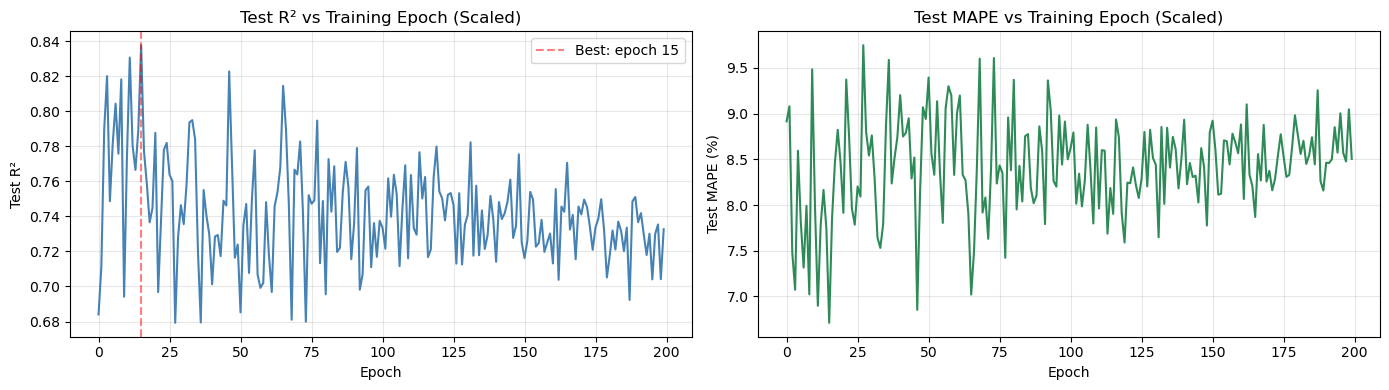

In [25]:
seed = 1
random.seed(seed)            
np.random.seed(seed)        
torch.manual_seed(seed)      
torch.cuda.manual_seed_all(seed)

# Tensors (scaled)
X_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_actual = y_test.values.flatten()

# Loader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# Model
input_dim = x_train_scaled.shape[1]
model = ElectricityDemandNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Track metrics per epoch
epoch_results_scaled = []

# Start timer
start_time = time.time()

for epoch in range(200):
    # Train
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train = train_loss / len(train_loader)
    
    # Evaluate on 2025 test set after this epoch
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_t).numpy()
    
    # Inverse-transform to real MW for metrics
    y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()
    
    # All metrics in real MW
    r2 = r2_score(y_test_actual, y_pred)
    mse = mean_squared_error(y_test_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred)
    mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
    bias = np.mean(y_pred - y_test_actual)
    
    epoch_results_scaled.append({
        'epoch': epoch,
        'train_loss': avg_train,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'bias': bias
    })
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Train Loss={avg_train:.4f}, R²={r2:.4f}, MAPE={mape:.2f}%, RMSE={rmse:.0f}")

# Stop timer
total_time = time.time() - start_time

# Find best epoch by R²
results_df_scaled = pd.DataFrame(epoch_results_scaled)
best_row = results_df_scaled.loc[results_df_scaled['r2'].idxmax()]

print("\n" + "="*60)
print(f"Best R² epoch (scaled): {int(best_row['epoch'])}")
print("Test Metrics - 2025:")
print(f"  R-squared:  {best_row['r2']:.4f}")
print(f"  MSE:   {best_row['mse']:.0f}")
print(f"  RMSE:  {best_row['rmse']:.0f} MW")
print(f"  MAE:   {best_row['mae']:.0f} MW")
print(f"  MAPE:  {best_row['mape']:.2f}%")
print(f"  Bias:  {best_row['bias']:.0f} MW")
print(f"Training time: {total_time:.3f} seconds (200 epochs)")
print("\n")

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(results_df_scaled['epoch'], results_df_scaled['r2'], color='steelblue')
axes[0].axvline(x=best_row['epoch'], color='red', linestyle='--', alpha=0.5, label=f"Best: epoch {int(best_row['epoch'])}")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test R²')
axes[0].set_title('Test R² vs Training Epoch (Scaled)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df_scaled['epoch'], results_df_scaled['mape'], color='seagreen')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test MAPE (%)')
axes[1].set_title('Test MAPE vs Training Epoch (Scaled)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()